In [3]:
import jax
import jax.numpy as jnp
import jax.image
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import os


Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


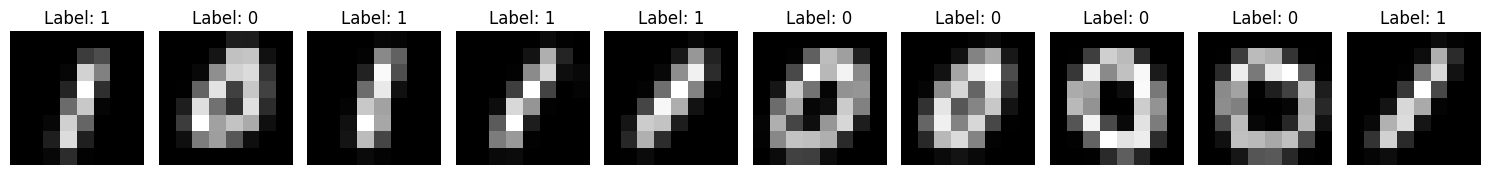

In [4]:
def load_and_preprocess_mnist_0s_and_1s():
    # Build and prepare the MNIST dataset using tensorflow_datasets.
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    # Load the training split as supervised (image, label) pairs.
    ds = ds_builder.as_dataset(split="train", as_supervised=True)
    
    # Filter the dataset to include only digits 0 and 1.
    ds = ds.filter(lambda image, label: tf.logical_or(tf.equal(label, 0), tf.equal(label, 1)))
    
    images_list = []
    labels_list = []
    
    # Iterate over the dataset. Each image is originally 28x28x1.
    for image, label in tfds.as_numpy(ds):
        # Normalize image to [0, 1].
        image = image.astype(np.float32) / 255.0
        
        # Convert to a JAX array.
        image_jax = jnp.array(image)
        
        # Downsample the image to 8x8. Preserve the channel dimension.
        resized = jax.image.resize(image_jax, shape=(8, 8, image_jax.shape[-1]), method='linear')
        
        images_list.append(resized)
        labels_list.append(label)
    
    # Stack the images and labels into arrays.
    images_array = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    
    return images_array, labels_array


def load_and_preprocess_mnist_0s():
    # Build and prepare the MNIST dataset using tensorflow_datasets.
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    # Load the training split as supervised (image, label) pairs.
    ds = ds_builder.as_dataset(split="train", as_supervised=True)
    
    # Filter the dataset to include only digit 0.
    ds = ds.filter(lambda image, label: tf.equal(label, 0))
    
    images_list = []
    labels_list = []
    
    # Iterate over the dataset. Each image is originally 28x28x1.
    for image, label in tfds.as_numpy(ds):
        # Normalize image to [0, 1].
        image = image.astype(np.float32) / 255.0
        
        # Convert to a JAX array.
        image_jax = jnp.array(image)
        
        # Downsample the image to 8x8. Preserve the channel dimension.
        resized = jax.image.resize(image_jax, shape=(8, 8, image_jax.shape[-1]), method='linear')
        
        images_list.append(resized)
        labels_list.append(label)
    
    # Stack the images and labels into arrays.
    images_array = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    
    return images_array, labels_array


def load_and_preprocess_mnist_1s():
    # Build and prepare the MNIST dataset using tensorflow_datasets.
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    # Load the training split as supervised (image, label) pairs.
    ds = ds_builder.as_dataset(split="train", as_supervised=True)
    
    # Filter the dataset to include only digit 1.
    ds = ds.filter(lambda image, label: tf.equal(label, 1))
    
    images_list = []
    labels_list = []
    
    # Iterate over the dataset. Each image is originally 28x28x1.
    for image, label in tfds.as_numpy(ds):
        # Normalize image to [0, 1].
        image = image.astype(np.float32) / 255.0
        
        # Convert to a JAX array.
        image_jax = jnp.array(image)
        
        # Downsample the image to 8x8. Preserve the channel dimension.
        resized = jax.image.resize(image_jax, shape=(8, 8, image_jax.shape[-1]), method='linear')
        
        images_list.append(resized)
        labels_list.append(label)
    
    # Stack the images and labels into arrays.
    images_array = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    
    return images_array, labels_array


In [ ]:

# # Load and preprocess the MNIST data.
# images, labels = load_and_preprocess_mnist_0s_and_1s()

# # Plot a few examples
# num_examples = 10  # number of examples to display
# fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

# for i in range(num_examples):
#     # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
#     img = images[i]
#     if img.shape[-1] == 1:
#         img = img.squeeze(-1)
    
#     axes[i].imshow(np.array(img), cmap='gray')
#     axes[i].axis('off')
#     axes[i].set_title(f"Label: {labels[i]}")

# plt.tight_layout()
# plt.show()

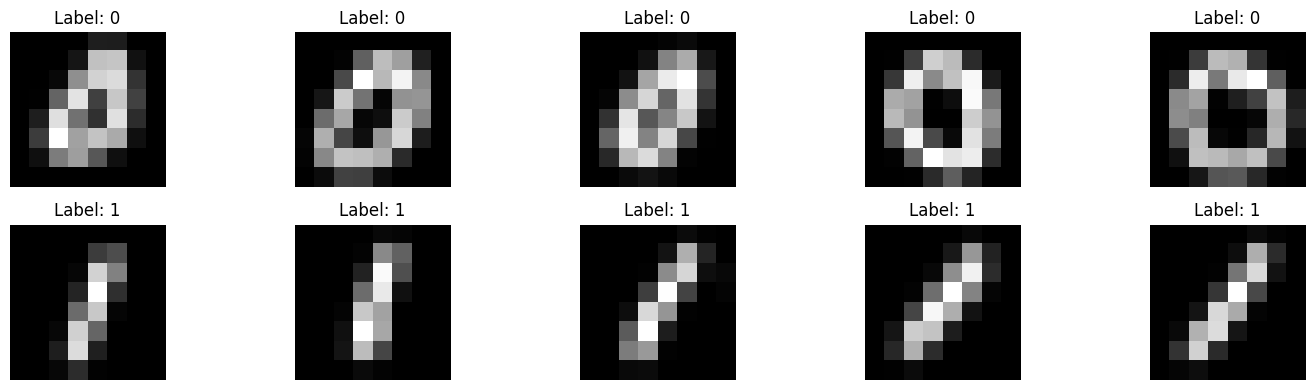

In [5]:
# Load and preprocess the MNIST data for 0s and 1s separately.
images_0s, labels_0s = load_and_preprocess_mnist_0s()
images_1s, labels_1s = load_and_preprocess_mnist_1s()

# Plot a few examples of 0s
num_examples = 5  # number of examples to display for each
fig, axes = plt.subplots(2, num_examples, figsize=(15, 4))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img_0 = images_0s[i]
    if img_0.shape[-1] == 1:
        img_0 = img_0.squeeze(-1)
    
    axes[0, i].imshow(np.array(img_0), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Label: {labels_0s[i]}")

# Plot a few examples of 1s
for i in range(num_examples):
    img_1 = images_1s[i]
    if img_1.shape[-1] == 1:
        img_1 = img_1.squeeze(-1)
    
    axes[1, i].imshow(np.array(img_1), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Label: {labels_1s[i]}")

plt.tight_layout()
plt.show()


In [6]:
# Remove the channel dimension (if it's 1) and reshape each image to a flat vector.
images_0s = jnp.squeeze(images_0s, axis=-1)  # Now shape is (num_samples, 8, 8)
images_flat_0s = images_0s.reshape(images_0s.shape[0], -1)  # Now shape is (num_samples, 64)

# Create the target directory if it doesn't exist.
save_folder = "data/MNIST/MNIST_0s_8x8pix"
os.makedirs(save_folder, exist_ok=True)

# Save the flattened jnp.array as a .npy file.
save_path = os.path.join(save_folder, "mnist_0s_8x8pix.npy")
np.save(save_path, np.array(images_flat_0s))  # Convert to numpy array for saving

print("Saved preprocessed data to:", save_path)

Saved preprocessed data to: data/MNIST/MNIST_0s_8x8pix/mnist_0s_8x8pix.npy


In [7]:
# Remove the channel dimension (if it's 1) and reshape each image to a flat vector.
images_1s = jnp.squeeze(images_1s, axis=-1)  # Now shape is (num_samples, 8, 8)
images_flat_1s = images_1s.reshape(images_1s.shape[0], -1)  # Now shape is (num_samples, 64)

# Create the target directory if it doesn't exist.
save_folder = "data/MNIST/MNIST_1s_8x8pix"
os.makedirs(save_folder, exist_ok=True)

# Save the flattened jnp.array as a .npy file.
save_path = os.path.join(save_folder, "mnist_1s_8x8pix.npy")
np.save(save_path, np.array(images_flat_1s))  # Convert to numpy array for saving

print("Saved preprocessed data to:", save_path)

Saved preprocessed data to: data/MNIST/MNIST_1s_8x8pix/mnist_1s_8x8pix.npy
